# 06 — LLM Zero-Shot Origin Classification (Qwen2.5-7B)

This notebook adds a **zero-shot LLM baseline** to the origin classification comparison. We use `Qwen2.5-7B-Instruct` loaded in 4-bit quantization (fits on 12GB VRAM) and prompt it to predict the origin country from the review text, without any fine-tuning.

**Why this matters for the paper:** A 2024+ NLP paper should answer the question "does task-specific fine-tuning still beat a strong off-the-shelf LLM?" If fine-tuned RoBERTa (Macro-F1 0.186) beats zero-shot Qwen2.5-7B, that justifies the fine-tuning pipeline. If Qwen wins, it's a significant finding.

**Setup:** uses the *same test split, same filtering, same seed* as notebook 04.1 for apples-to-apples comparison.

**Requirements:** `pip install bitsandbytes accelerate` (on top of existing `transformers`, `torch`).

In [1]:
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

In [2]:
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
MODEL_CHECKPOINT = 'Qwen/Qwen2.5-7B-Instruct'
TEXT_COLUMN = 'text_basic_plus_aspects'
MAX_NEW_TOKENS = 20  # we only need a short answer
BATCH_SIZE = 4       # adjust down if OOM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')

Device: cuda
GPU: NVIDIA GeForce RTX 4070


## Load and split data (identical to 04.1)

In [3]:
df = pd.read_csv('Data/final_coffee_reviews.csv')

def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def normalize_text(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['text_basic'] = df['Blind Assessment'].fillna('').map(normalize_text)

for col in ['aroma_text', 'flavor_text', 'acidity_text', 'body_text', 'combined_text']:
    if col not in df.columns:
        df[col] = ''
    df[col] = df[col].fillna('').astype(str)

df['aspect_text_combined'] = df['combined_text'].map(normalize_text)
df['text_basic_plus_aspects'] = (
    df['text_basic'].fillna('') + ' ' + df['aspect_text_combined'].fillna('')
).str.replace(r'\s+', ' ', regex=True).str.strip()

df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

y = work['origin_country']
row_idx = work.index
train_idx, temp_idx, _, y_temp = train_test_split(row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
val_idx, test_idx, _, _ = train_test_split(temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

test_df = work.loc[test_idx].reset_index(drop=True)
label_names = sorted(work['origin_country'].unique())

print(f'Test samples: {len(test_df)}, Classes: {len(label_names)}')
print('Classes:', label_names)

Test samples: 1023, Classes: 15
Classes: ['Brazil', 'Colombia', 'Costa Rica', 'El Salvador', 'Ethiopia', 'Guatemala', 'Honduras', 'Indonesia', 'Kenya', 'Mexico', 'Nicaragua', 'Panama', 'Peru', 'Rwanda', 'United States']


## Load Qwen2.5-7B-Instruct in 4-bit

In [4]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_CHECKPOINT,
    quantization_config=bnb_config,
    device_map='auto',
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# CRITICAL for batched decoder-only generation — right-padding causes the model
# to generate after pad tokens instead of after the real prompt, producing garbage.
tokenizer.padding_side = 'left'

print('Model loaded.')
print(f'Padding side: {tokenizer.padding_side}')
print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded.
Padding side: left
VRAM used: 5.56 GB


## Prompt design + output parser

In [5]:
country_list_str = ', '.join(label_names)

# Few-shot examples drawn from the TRAIN split (never test) using distinctive origins.
# Each example shows the required output format: country name only, on its own line.
FEW_SHOT_EXAMPLES = [
    {
        'review': 'bright floral jasmine lemon bergamot in aroma sweetly tart juicy acidity silky mouthfeel',
        'country': 'Ethiopia',
    },
    {
        'review': 'black currant tomato cedar in aroma and cup wine like acidity full syrupy mouthfeel savory finish',
        'country': 'Kenya',
    },
    {
        'review': 'earthy herbal cedar tobacco mushroom full heavy body low acidity pungent finish',
        'country': 'Indonesia',
    },
    {
        'review': 'roasted nuts milk chocolate caramel low acidity smooth medium body sweet finish',
        'country': 'Brazil',
    },
    {
        'review': 'balanced chocolate caramel almond medium acidity round mouthfeel clean finish',
        'country': 'Colombia',
    },
]

SYSTEM_PROMPT = (
    "You are a coffee-origin classifier. Given a coffee review, reply with the country of origin.\n"
    f"Valid countries (pick exactly one): {country_list_str}.\n"
    "RULES:\n"
    "1. Output ONLY the country name from the list above.\n"
    "2. No explanation, no punctuation, no quotes, no prefix words like 'Answer:' or 'Country:'.\n"
    "3. Exactly one country name on a single line. Nothing else."
)

def build_prompt(review_text: str) -> str:
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]
    for ex in FEW_SHOT_EXAMPLES:
        messages.append({'role': 'user', 'content': f'Review: {ex["review"]}'})
        messages.append({'role': 'assistant', 'content': ex['country']})
    messages.append({'role': 'user', 'content': f'Review: {review_text}'})
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# Show what the model will see for one example
example_prompt = build_prompt(test_df[TEXT_COLUMN].iloc[0][:200])
print(example_prompt[-1200:])
print(f'\n[Prompt token length: {len(tokenizer.encode(example_prompt))}]')

 punctuation, no quotes, no prefix words like 'Answer:' or 'Country:'.
3. Exactly one country name on a single line. Nothing else.<|im_end|>
<|im_start|>user
Review: bright floral jasmine lemon bergamot in aroma sweetly tart juicy acidity silky mouthfeel<|im_end|>
<|im_start|>assistant
Ethiopia<|im_end|>
<|im_start|>user
Review: black currant tomato cedar in aroma and cup wine like acidity full syrupy mouthfeel savory finish<|im_end|>
<|im_start|>assistant
Kenya<|im_end|>
<|im_start|>user
Review: earthy herbal cedar tobacco mushroom full heavy body low acidity pungent finish<|im_end|>
<|im_start|>assistant
Indonesia<|im_end|>
<|im_start|>user
Review: roasted nuts milk chocolate caramel low acidity smooth medium body sweet finish<|im_end|>
<|im_start|>assistant
Brazil<|im_end|>
<|im_start|>user
Review: balanced chocolate caramel almond medium acidity round mouthfeel clean finish<|im_end|>
<|im_start|>assistant
Colombia<|im_end|>
<|im_start|>user
Review: subtle savory deep dark chocolate

In [6]:
def parse_country(output: str, valid_labels: list[str]) -> str:
    """Map model output to one of the valid labels. Returns the first match,
    or 'UNKNOWN' if nothing matches."""
    output = output.strip().lower()
    # Try exact label match first
    for label in valid_labels:
        if label.lower() == output:
            return label
    # Try substring match (handles "Ethiopia.", "Ethiopia (Yirgacheffe)", etc.)
    for label in valid_labels:
        if label.lower() in output:
            return label
    return 'UNKNOWN'

# Quick sanity check
for t in ['Ethiopia', 'ethiopia.', 'The origin is Kenya.', 'probably united states', 'nonsense']:
    print(repr(t), '->', parse_country(t, label_names))

'Ethiopia' -> Ethiopia
'ethiopia.' -> Ethiopia
'The origin is Kenya.' -> Kenya
'probably united states' -> United States
'nonsense' -> UNKNOWN


In [7]:
# Sanity check: run on 8 samples first. If this returns garbage or >20% UNKNOWN,
# STOP and fix the prompt/padding before running the full loop.
_sanity_n = 8
_sanity_texts = test_df[TEXT_COLUMN].iloc[:_sanity_n].tolist()
_sanity_true  = test_df['origin_country'].iloc[:_sanity_n].tolist()
_sanity_prompts = [build_prompt(t) for t in _sanity_texts]

_inputs = tokenizer(_sanity_prompts, return_tensors='pt', padding=True, truncation=True, max_length=1024).to(DEVICE)
with torch.no_grad():
    _outs = model.generate(
        **_inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
_input_len = _inputs['input_ids'].shape[1]
print('=== Sanity check (first 8 test samples) ===')
for i, out in enumerate(_outs):
    gen = tokenizer.decode(out[_input_len:], skip_special_tokens=True).strip()
    pred = parse_country(gen, label_names)
    ok = '✓' if pred == _sanity_true[i] else '✗'
    print(f'{ok} true={_sanity_true[i]:15s} | pred={pred:15s} | raw={gen!r}')

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Sanity check (first 8 test samples) ===
✓ true=Kenya           | pred=Kenya           | raw='Kenya'
✗ true=Ethiopia        | pred=Costa Rica      | raw='Costa Rica'
✗ true=Ethiopia        | pred=Panama          | raw='Panama'
✗ true=Kenya           | pred=Panama          | raw='Panama'
✗ true=Guatemala       | pred=Costa Rica      | raw='Costa Rica'
✗ true=Ethiopia        | pred=Colombia        | raw='Colombia'
✗ true=Guatemala       | pred=Costa Rica      | raw='Costa Rica'
✗ true=Colombia        | pred=Panama          | raw='Panama'


## Run zero-shot inference on the test set

Processes in batches of `BATCH_SIZE`. Expect ~5–15 min on a 4070 for 1023 samples.

In [8]:
test_texts = test_df[TEXT_COLUMN].tolist()
test_labels = test_df['origin_country'].tolist()

prompts = [build_prompt(t) for t in test_texts]

raw_outputs = []
predicted_labels = []
start = time.time()

for batch_start in range(0, len(prompts), BATCH_SIZE):
    batch = prompts[batch_start:batch_start+BATCH_SIZE]
    inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=1024).to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.pad_token_id,
        )
    # Decode only the newly generated tokens
    input_len = inputs['input_ids'].shape[1]
    for i, out in enumerate(outputs):
        gen = tokenizer.decode(out[input_len:], skip_special_tokens=True)
        raw_outputs.append(gen)
        predicted_labels.append(parse_country(gen, label_names))

    if (batch_start // BATCH_SIZE) % 10 == 0:
        elapsed = time.time() - start
        done = batch_start + len(batch)
        eta = elapsed / max(done, 1) * (len(prompts) - done)
        print(f'  {done}/{len(prompts)} | elapsed {elapsed:.0f}s | ETA {eta:.0f}s')

print(f'\nTotal inference time: {time.time()-start:.0f}s')
print(f'UNKNOWN predictions: {predicted_labels.count("UNKNOWN")} / {len(predicted_labels)}')

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  4/1023 | elapsed 1s | ETA 252s
  44/1023 | elapsed 11s | ETA 235s
  84/1023 | elapsed 20s | ETA 225s
  124/1023 | elapsed 30s | ETA 215s
  164/1023 | elapsed 39s | ETA 206s
  204/1023 | elapsed 49s | ETA 195s
  244/1023 | elapsed 58s | ETA 187s
  284/1023 | elapsed 68s | ETA 177s
  324/1023 | elapsed 78s | ETA 168s
  364/1023 | elapsed 88s | ETA 159s
  404/1023 | elapsed 97s | ETA 148s
  444/1023 | elapsed 107s | ETA 139s
  484/1023 | elapsed 117s | ETA 130s
  524/1023 | elapsed 126s | ETA 120s
  564/1023 | elapsed 136s | ETA 110s
  604/1023 | elapsed 145s | ETA 101s
  644/1023 | elapsed 155s | ETA 91s
  684/1023 | elapsed 164s | ETA 81s
  724/1023 | elapsed 174s | ETA 72s
  764/1023 | elapsed 184s | ETA 62s
  804/1023 | elapsed 194s | ETA 53s
  844/1023 | elapsed 204s | ETA 43s
  884/1023 | elapsed 213s | ETA 34s
  924/1023 | elapsed 223s | ETA 24s
  964/1023 | elapsed 232s | ETA 14s
  1004/1023 | elapsed 242s | ETA 5s

Total inference time: 246s
UNKNOWN predictions: 4 / 1023


## Evaluate

In [9]:
# Filter out UNKNOWN for computing metrics (or treat as wrong — we do the latter)
# Treating UNKNOWN as wrong is fairer: the model failed to produce a valid label.

acc = accuracy_score(test_labels, predicted_labels)
bal_acc = balanced_accuracy_score(test_labels, predicted_labels)
prec, rec, f1, _ = precision_recall_fscore_support(test_labels, predicted_labels, average='macro', zero_division=0)

print('=== Qwen2.5-7B Zero-Shot Test Results ===')
print(f'Accuracy:          {acc:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print(f'Macro Precision:   {prec:.4f}')
print(f'Macro Recall:      {rec:.4f}')
print(f'Macro-F1:          {f1:.4f}')
print()
print('--- vs prior results ---')
print('TF-IDF baseline:       Macro-F1 0.144')
print('RoBERTa fine-tuned:    Macro-F1 0.186')
print(f'Qwen2.5-7B zero-shot:  Macro-F1 {f1:.4f}')

class_order = work['origin_country'].value_counts().index.tolist()
print('\nPer-class report:')
print(classification_report(test_labels, predicted_labels, labels=class_order, zero_division=0, digits=3))

=== Qwen2.5-7B Zero-Shot Test Results ===
Accuracy:          0.1222
Balanced Accuracy: 0.0950
Macro Precision:   0.1981
Macro Recall:      0.0891
Macro-F1:          0.0646

--- vs prior results ---
TF-IDF baseline:       Macro-F1 0.144
RoBERTa fine-tuned:    Macro-F1 0.186
Qwen2.5-7B zero-shot:  Macro-F1 0.0646

Per-class report:
               precision    recall  f1-score   support

     Ethiopia      0.362     0.084     0.136       299
     Colombia      0.179     0.081     0.112       148
        Kenya      0.647     0.105     0.180       105
    Guatemala      0.107     0.548     0.180        84
    Indonesia      0.250     0.044     0.075        68
   Costa Rica      0.046     0.179     0.074        56
       Panama      0.078     0.302     0.124        53
United States      0.000     0.000     0.000        45
  El Salvador      1.000     0.028     0.054        36
       Brazil      0.000     0.000     0.000        30
       Rwanda      0.000     0.000     0.000        27
       

G:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


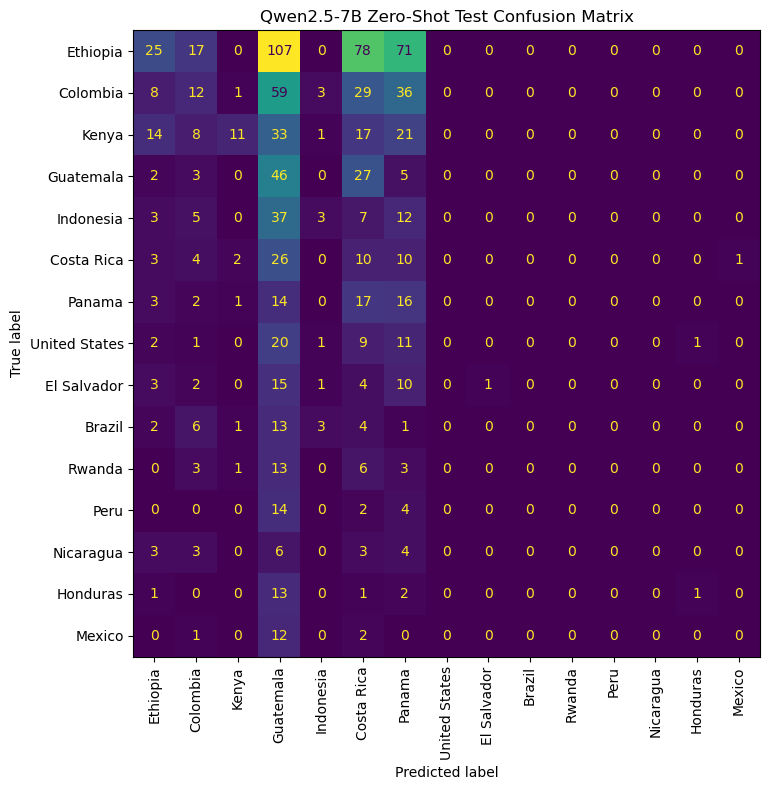

In [10]:
cm = confusion_matrix(test_labels, predicted_labels, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('Qwen2.5-7B Zero-Shot Test Confusion Matrix')
plt.tight_layout()
plt.show()

In [11]:
import os
os.makedirs('artifacts/llm_zero_shot', exist_ok=True)

results = {
    'model': MODEL_CHECKPOINT,
    'method': 'zero-shot',
    'accuracy': acc,
    'balanced_accuracy': bal_acc,
    'macro_precision': prec,
    'macro_recall': rec,
    'macro_f1': f1,
    'n_unknown': predicted_labels.count('UNKNOWN'),
    'n_test': len(test_labels),
}
with open('artifacts/llm_zero_shot/results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save predictions for error analysis
pred_df = pd.DataFrame({
    'text': test_texts,
    'true': test_labels,
    'pred': predicted_labels,
    'raw_output': raw_outputs,
})
pred_df.to_csv('artifacts/llm_zero_shot/predictions.csv', index=False)
print('Saved.')

Saved.


## Interpretation

- If Qwen2.5-7B zero-shot **beats** RoBERTa fine-tuned (0.186): strong evidence that modern LLMs make task-specific fine-tuning unnecessary for this problem. Big finding.
- If Qwen2.5-7B **loses** to RoBERTa: the fine-tuning pipeline is justified. Still a valuable comparison — shows small specialized models beat large general models on narrow tasks.
- Check the `UNKNOWN` count. If high, the parser or prompt needs work.
- Look at per-class report: does Qwen handle the tail classes better than RoBERTa? LLMs often do because they've seen origin-related text in pretraining.